# Data loading & preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Uber-Jan-Feb-FOIL.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Map base codes to names (extra initiative — makes output readable)
base_names = {
    'B02512': 'Unter', 'B02765': 'Grun', 'B02764': 'Danach-NY',
    'B02682': 'Schmecken', 'B02617': 'Weiter', 'B02598': 'Hinter'
}
df['base_name'] = df['dispatching_base_number'].map(base_names)

print(df.info())
print(df.describe())
print("Missing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   dispatching_base_number  354 non-null    object        
 1   date                     354 non-null    datetime64[ns]
 2   active_vehicles          354 non-null    int64         
 3   trips                    354 non-null    int64         
 4   base_name                354 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 14.0+ KB
None
                      date  active_vehicles         trips
count                  354       354.000000    354.000000
mean   2015-01-30 00:00:00      1307.435028  11667.316384
min    2015-01-01 00:00:00       112.000000    629.000000
25%    2015-01-15 00:00:00       296.750000   2408.500000
50%    2015-01-30 00:00:00      1077.000000   9601.000000
75%    2015-02-14 00:00:00      1417.000000  1

# Exploratory data analysis (EDA)

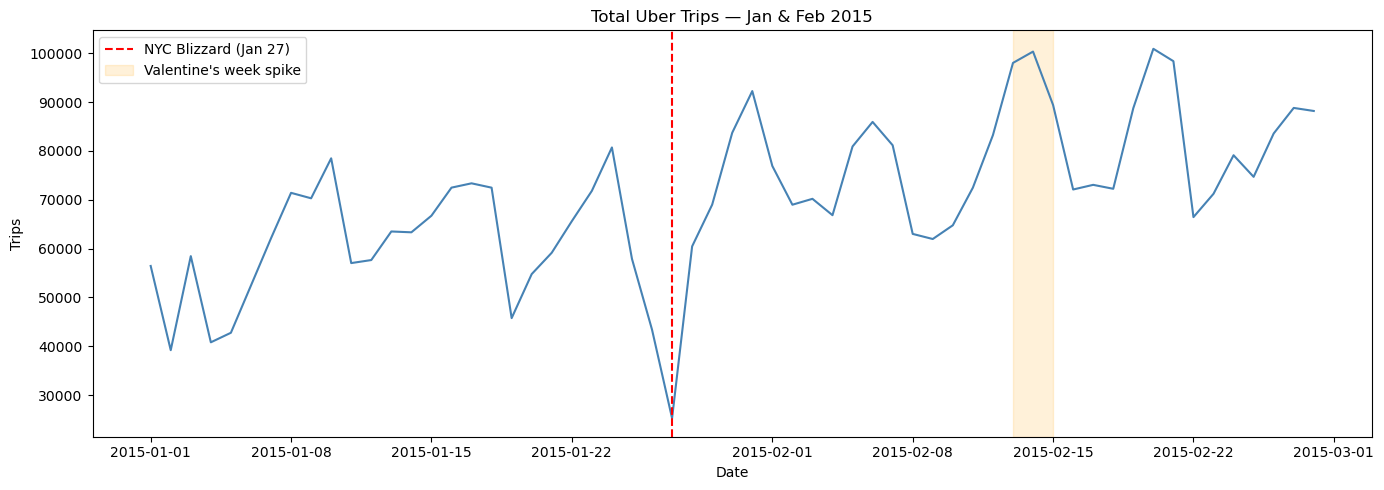

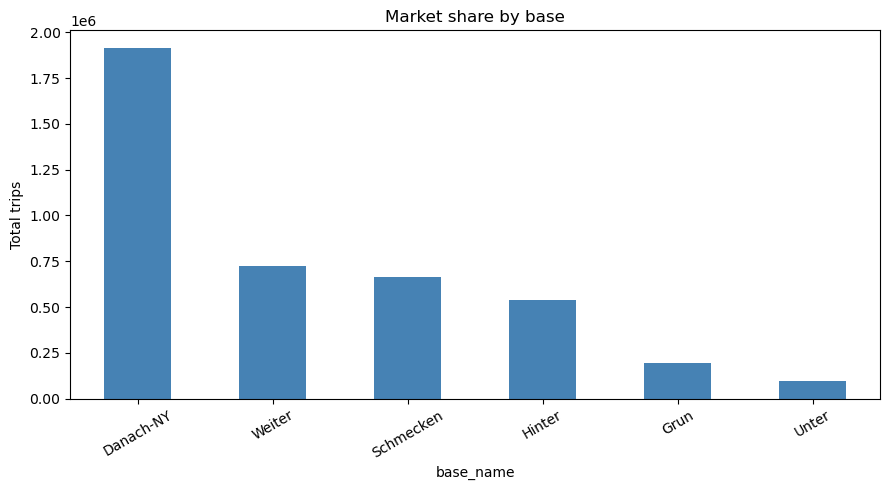

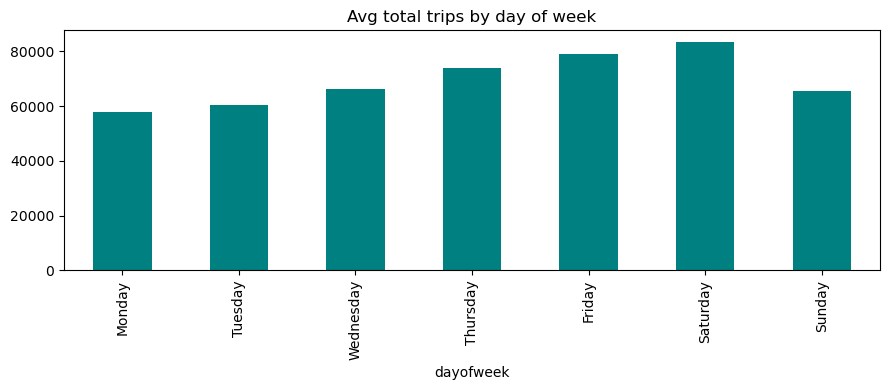

In [2]:
# Daily totals across all bases
daily = df.groupby('date')[['trips','active_vehicles']].sum().reset_index()
daily['month'] = daily['date'].dt.month_name()

plt.figure(figsize=(14,5))
plt.plot(daily['date'], daily['trips'], color='steelblue', lw=1.5)
plt.axvline(pd.Timestamp('2015-01-27'), color='red', linestyle='--', label='NYC Blizzard (Jan 27)')
plt.axvspan(pd.Timestamp('2015-02-13'), pd.Timestamp('2015-02-15'),
            alpha=0.15, color='orange', label="Valentine's week spike")
plt.title("Total Uber Trips — Jan & Feb 2015")
plt.xlabel("Date"); plt.ylabel("Trips")
plt.legend(); plt.tight_layout(); plt.show()

# Market share by base
base_share = df.groupby('base_name')['trips'].sum().sort_values(ascending=False)
base_share.plot(kind='bar', figsize=(9,5), color='steelblue', title='Market share by base')
plt.ylabel('Total trips'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

# Day-of-week pattern (EXTRA — not in PDF)
daily['dayofweek'] = daily['date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = daily.groupby('dayofweek')['trips'].mean().reindex(dow_order)
dow_avg.plot(kind='bar', figsize=(9,4), color='teal', title='Avg total trips by day of week')
plt.tight_layout(); plt.show()

# Feature engineering (the differentiator)

In [3]:
# Aggregate to daily level first
daily = df.groupby('date').agg(
    total_trips=('trips','sum'),
    total_vehicles=('active_vehicles','sum'),
    active_bases=('dispatching_base_number','nunique')
).reset_index()

# Standard time features
daily['dayofweek']    = daily['date'].dt.dayofweek       # 0=Mon
daily['day']          = daily['date'].dt.day
daily['month']        = daily['date'].dt.month
daily['week_number']  = daily['date'].dt.isocalendar().week.astype(int)
daily['is_weekend']   = (daily['dayofweek'] >= 5).astype(int)

# EXTRA FEATURES — what makes your project stand out:
# 1. Fleet efficiency (trips per active vehicle — a business KPI)
daily['trips_per_vehicle'] = daily['total_trips'] / daily['total_vehicles']

# 2. Rolling 7-day average (trend smoothing)
daily['rolling_7d'] = daily['total_trips'].rolling(7, min_periods=1).mean()

# 3. Anomaly flag — Z-score based (blizzard detection)
from scipy import stats
daily['z_score'] = np.abs(stats.zscore(daily['total_trips']))
daily['is_anomaly'] = (daily['z_score'] > 2).astype(int)

# 4. Special event flags (domain knowledge = initiative)
daily['is_valentine'] = daily['date'].isin(
    pd.date_range('2015-02-13','2015-02-15')).astype(int)
daily['is_blizzard'] = (daily['date'] == pd.Timestamp('2015-01-27')).astype(int)

# 5. Month-over-month growth per base (competitive intelligence)
base_monthly = df.groupby(['dispatching_base_number','date'])['active_vehicles'].sum().reset_index()
base_monthly['month'] = base_monthly['date'].dt.month
mom = base_monthly.groupby(['dispatching_base_number','month'])['active_vehicles'].mean().unstack()
mom['growth_pct'] = ((mom[2] - mom[1]) / mom[1] * 100).round(1)
print(mom[['growth_pct']].rename(index=base_names))

print(daily.head())

month                    growth_pct
dispatching_base_number            
Unter                          13.9
Hinter                         12.8
Weiter                          8.4
Schmecken                      22.3
Danach-NY                      10.5
Grun                          108.2
        date  total_trips  total_vehicles  active_bases  dayofweek  day  \
0 2015-01-01        56437            6885             6          3    1   
1 2015-01-02        39189            6330             6          4    2   
2 2015-01-03        58449            6510             6          5    3   
3 2015-01-04        40798            5838             6          6    4   
4 2015-01-05        42752            6884             6          0    5   

   month  week_number  is_weekend  trips_per_vehicle    rolling_7d   z_score  \
0      1            1           0           8.197095  56437.000000  0.864276   
1      1            1           0           6.190995  47813.000000  1.963055   
2      1            1

# Model building

In [4]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [5]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error
import xgboost as xgb

features = ['dayofweek','day','month','week_number','is_weekend',
            'trips_per_vehicle','rolling_7d','is_valentine','is_blizzard']
target = 'total_trips'

X = daily[features].fillna(0)
y = daily[target]

# Time-series aware split (don't shuffle!)
split_idx = int(len(daily) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

tscv = TimeSeriesSplit(n_splits=5)

# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=4,
                               learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print(f"XGBoost MAPE: {mean_absolute_percentage_error(y_test, xgb_pred):.2%}")

# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print(f"Random Forest MAPE: {mean_absolute_percentage_error(y_test, rf_pred):.2%}")

# Gradient Boosting
gbr_model = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                       learning_rate=0.1, random_state=42)
gbr_model.fit(X_train, y_train)
gbr_pred = gbr_model.predict(X_test)
print(f"GBTR MAPE: {mean_absolute_percentage_error(y_test, gbr_pred):.2%}")

XGBoost MAPE: 6.69%
Random Forest MAPE: 6.69%
GBTR MAPE: 5.75%


# Evaluation & visualization

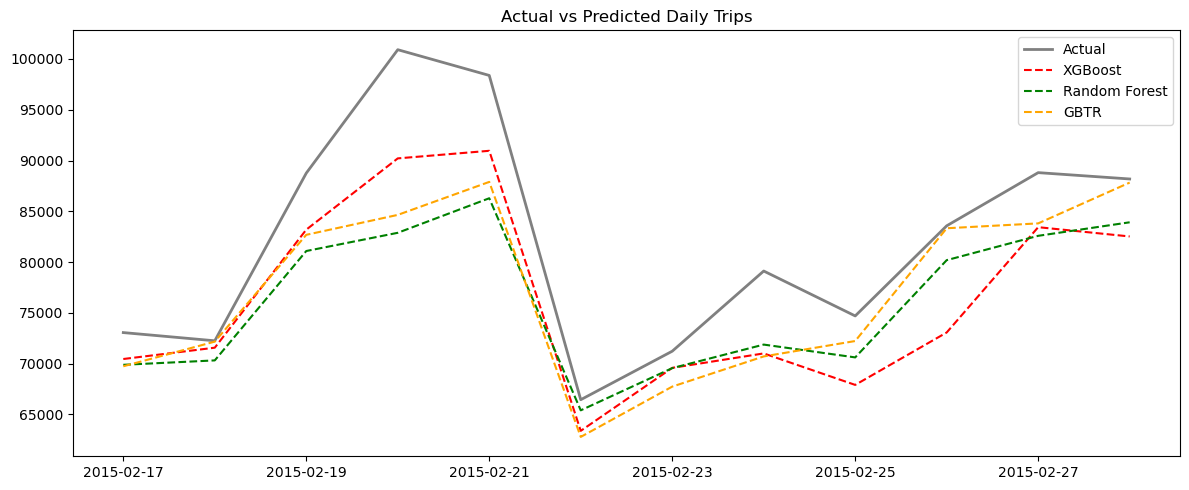

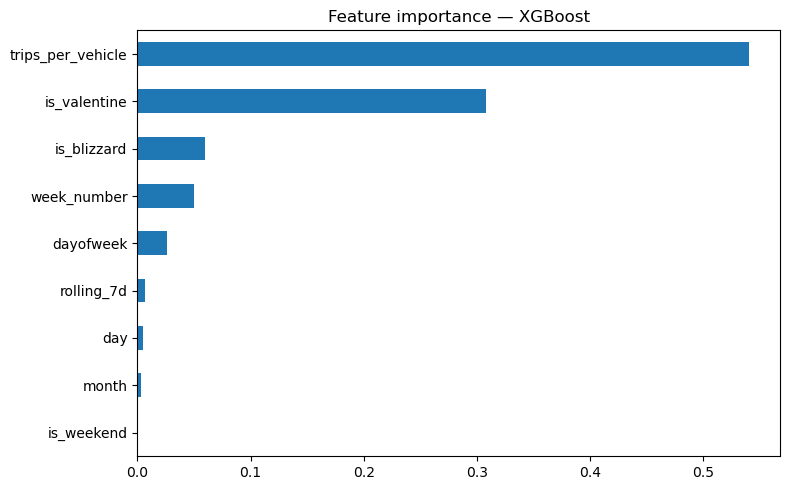

In [6]:
# Actual vs predicted plot
test_dates = daily['date'].iloc[split_idx:]
plt.figure(figsize=(12,5))
plt.plot(test_dates, y_test.values, label='Actual', color='gray', lw=2)
plt.plot(test_dates, xgb_pred, label='XGBoost', color='red', linestyle='--', lw=1.5)
plt.plot(test_dates, rf_pred, label='Random Forest', color='green', linestyle='--', lw=1.5)
plt.plot(test_dates, gbr_pred, label='GBTR', color='orange', linestyle='--', lw=1.5)
plt.title('Actual vs Predicted Daily Trips'); plt.legend(); plt.tight_layout(); plt.show()

# Feature importance (EXTRA — business storytelling)
feat_imp = pd.Series(xgb_model.feature_importances_, index=features).sort_values()
feat_imp.plot(kind='barh', figsize=(8,5), title='Feature importance — XGBoost')
plt.tight_layout(); plt.show()

# Ensemble

In [7]:
ensemble_pred = 0.368 * xgb_pred + 0.322 * rf_pred + 0.310 * gbr_pred
print(f"Ensemble MAPE: {mean_absolute_percentage_error(y_test, ensemble_pred):.2%}")

Ensemble MAPE: 6.40%
